k=2, silhouette score = 0.306
k=3, silhouette score = 0.351
k=4, silhouette score = 0.372
k=5, silhouette score = 0.302
k=6, silhouette score = 0.309
k=7, silhouette score = 0.293

Оптимальное число кластеров по силуэту: k = 4 (score = 0.372)


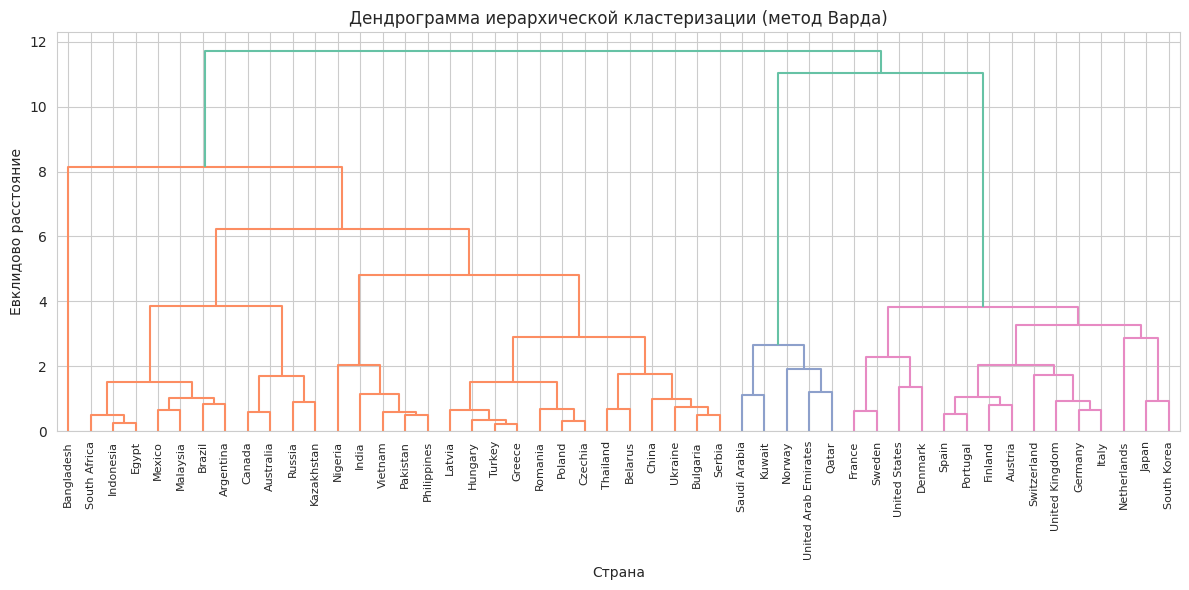

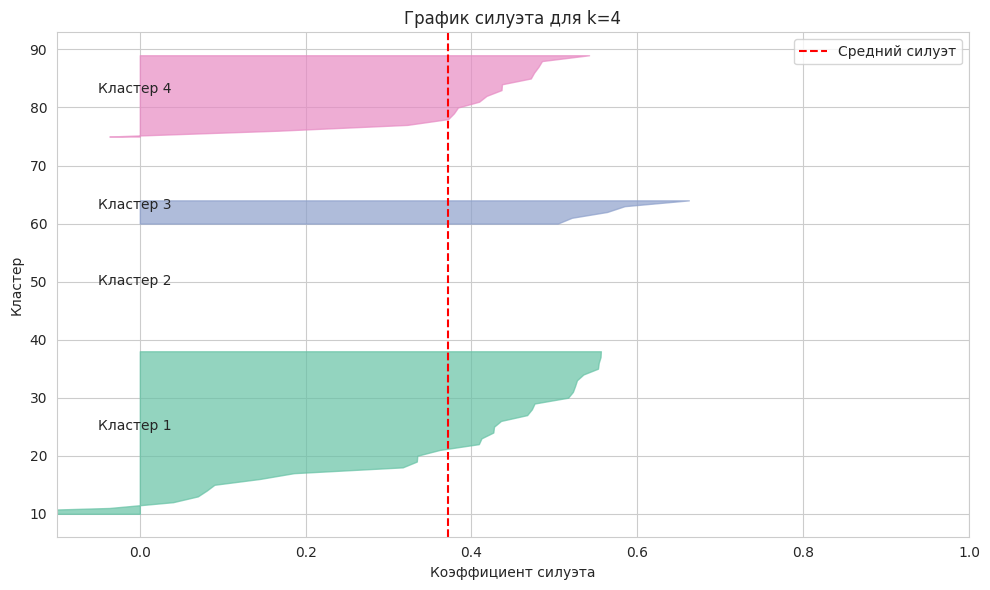

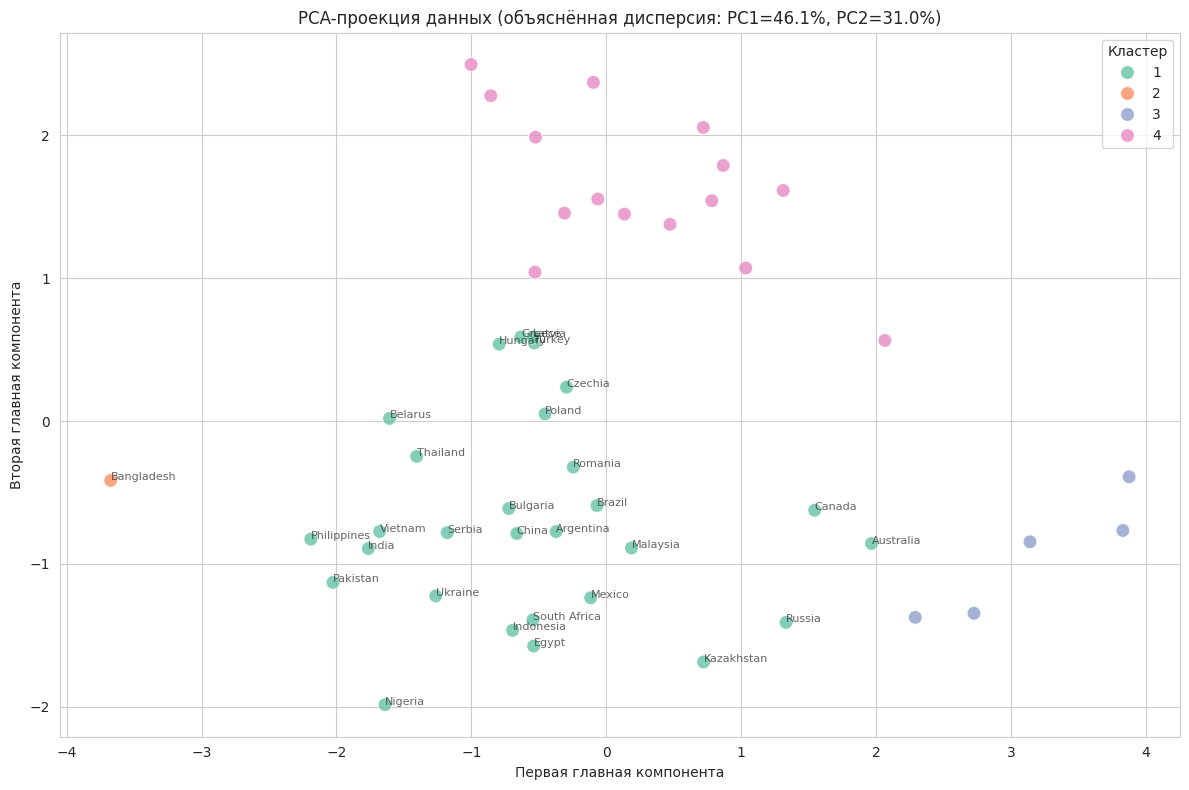

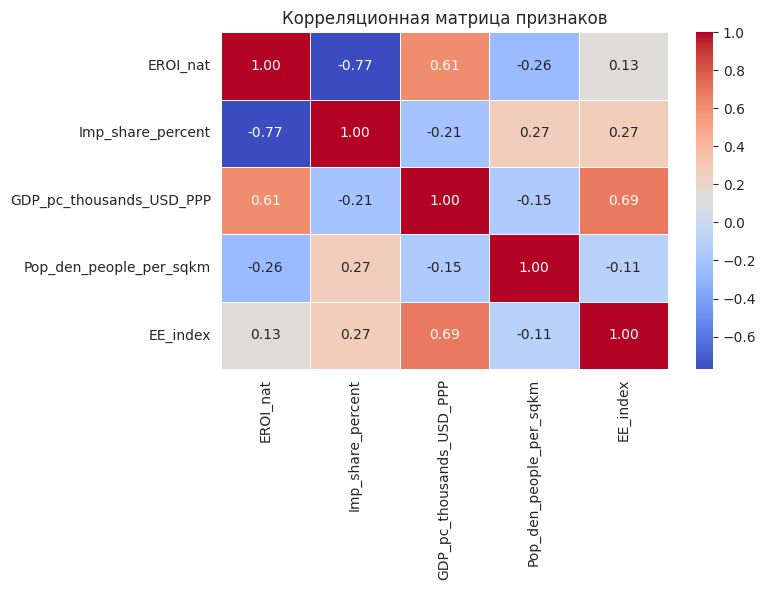

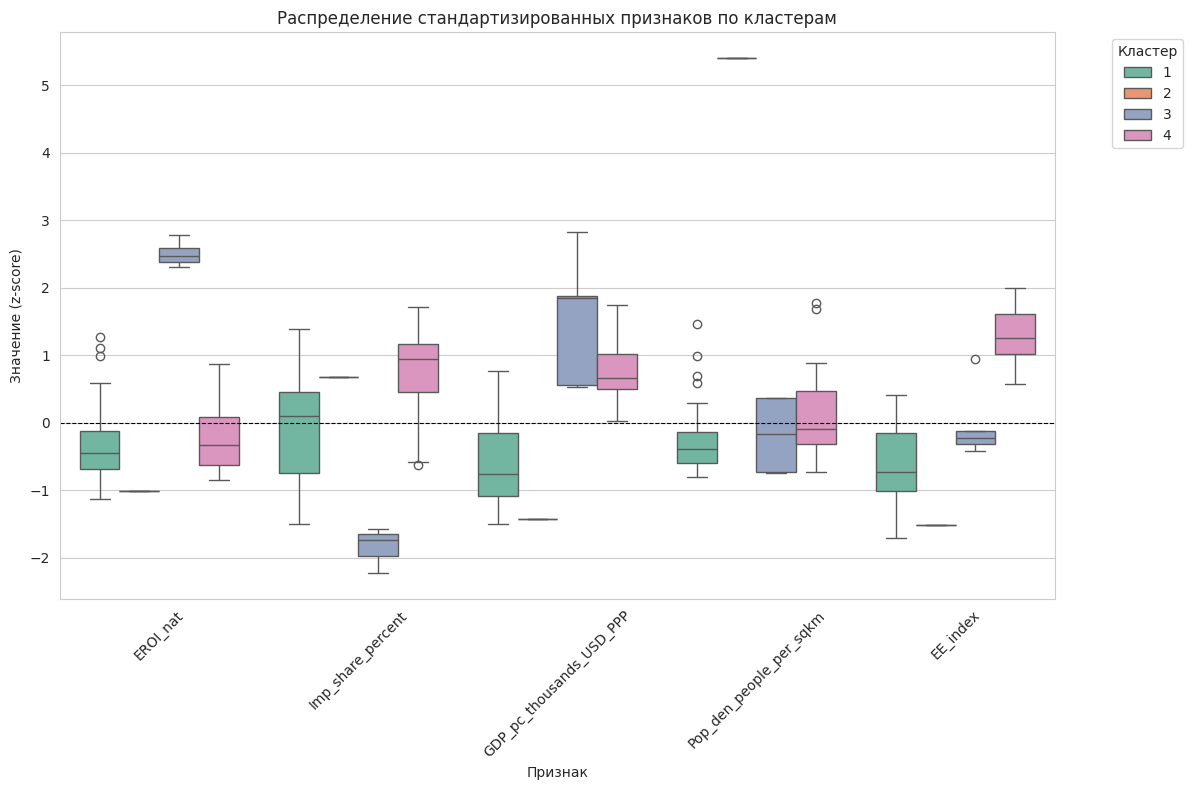

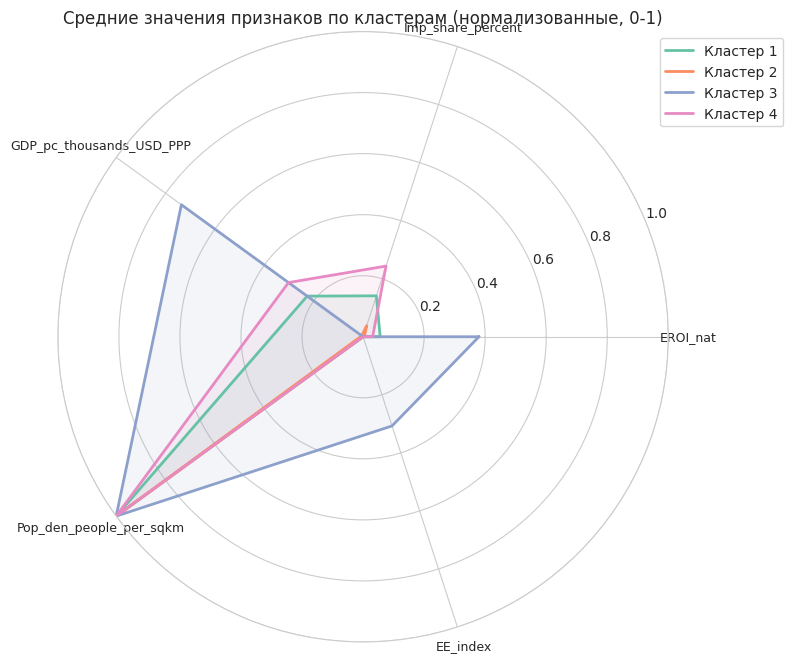

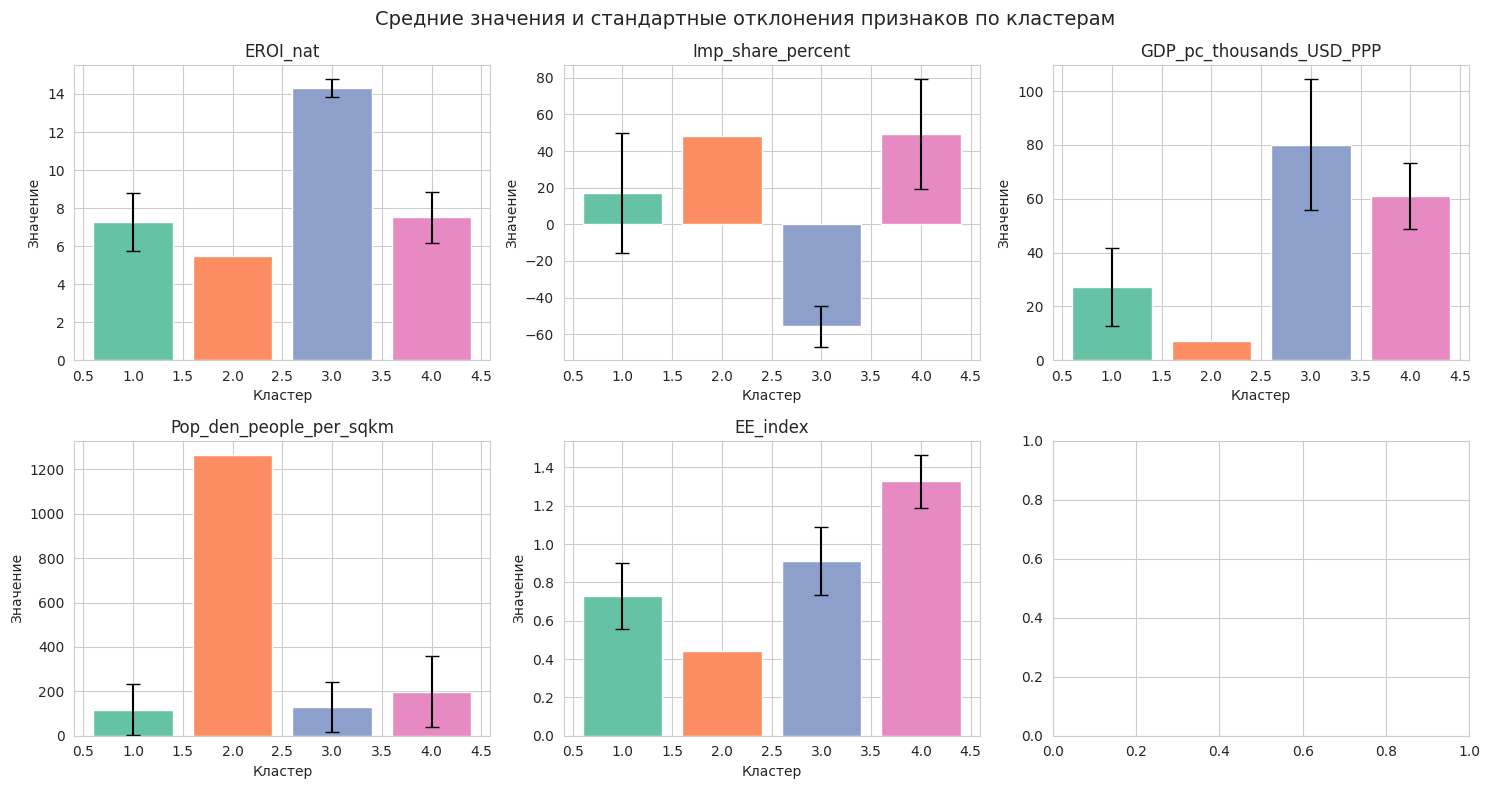


Результаты кластеризации сохранены в 'cluster_results_with_pca.csv'

Средние значения признаков по кластерам:
         EROI_nat  Imp_share_percent  GDP_pc_thousands_USD_PPP  \
cluster                                                          
1            7.29              17.24                     27.25   
2            5.50              48.00                      7.10   
3           14.30             -55.80                     80.04   
4            7.52              49.47                     61.05   

         Pop_den_people_per_sqkm  EE_index  
cluster                                     
1                         117.84      0.73  
2                        1265.00      0.44  
3                         128.80      0.91  
4                         199.07      1.33  

Количество стран в каждом кластере:
cluster
1    29
2     1
3     5
4    15
Name: count, dtype: int64


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from scipy.spatial.distance import pdist
from sklearn.metrics import silhouette_score, silhouette_samples

# =============================================
# 1. Загрузка и предобработка данных
# =============================================

df = pd.read_csv('data_50_countries.csv')
features = ['EROI_nat', 'Imp_share_percent', 'GDP_pc_thousands_USD_PPP',
            'Pop_den_people_per_sqkm', 'EE_index']
X = df[features].copy()

# Стандартизация
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# =============================================
# 2. Иерархическая кластеризация (метод Варда)
# =============================================

# Вычисление матрицы расстояний и связей
Z = linkage(X_scaled, method='ward', metric='euclidean')

# Определение оптимального числа кластеров по силуэту (диапазон 2-7)
sil_scores = []
for k in range(2, 8):
    labels = fcluster(Z, k, criterion='maxclust')
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f'k={k}, silhouette score = {score:.3f}')

best_k = np.argmax(sil_scores) + 2
print(f'\nОптимальное число кластеров по силуэту: k = {best_k} (score = {sil_scores[best_k-2]:.3f})')

# Фиксация кластеров
df['cluster'] = fcluster(Z, best_k, criterion='maxclust')
cluster_labels = df['cluster'].values

# =============================================
# 3. Визуализация
# =============================================

sns.set_style('whitegrid')
sns.set_palette('Set2')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 10

# 3.1 Дендрограмма
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=df['country_name'].values, leaf_rotation=90, leaf_font_size=8,
           color_threshold=0.7*max(Z[:,2]))
plt.title('Дендрограмма иерархической кластеризации (метод Варда)')
plt.xlabel('Страна')
plt.ylabel('Евклидово расстояние')
plt.tight_layout()
plt.savefig('dendrogram.png', dpi=150)
plt.show()

# 3.2 График силуэта для оптимального k
from sklearn.metrics import silhouette_samples

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
silhouette_vals = silhouette_samples(X_scaled, cluster_labels)
for i in range(1, best_k+1):
    ith_cluster_sil_vals = silhouette_vals[cluster_labels == i]
    ith_cluster_sil_vals.sort()
    size_cluster = ith_cluster_sil_vals.shape[0]
    y_upper = y_lower + size_cluster
    color = sns.color_palette('Set2')[i-1]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + size_cluster/2, f'Кластер {i}', fontsize=10)
    y_lower = y_upper + 10

ax.axvline(x=silhouette_score(X_scaled, cluster_labels), color='red', linestyle='--', label='Средний силуэт')
ax.set_xlabel('Коэффициент силуэта')
ax.set_ylabel('Кластер')
ax.set_title(f'График силуэта для k={best_k}')
ax.legend()
ax.set_xlim([-0.1, 1])
plt.tight_layout()
plt.savefig('silhouette_plot.png', dpi=150)
plt.show()

# 3.3 PCA двумерная проекция с цветом кластеров
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['cluster'] = cluster_labels
df_pca['country'] = df['country_name']

plt.figure(figsize=(12, 8))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='cluster', palette='Set2', s=100, alpha=0.8)
# Добавим подписи для некоторых стран (опционально)
for i, row in df_pca.iterrows():
    if row['cluster'] == 1 or row['cluster'] == 2 or row['country'] in ['USA', 'CHN', 'RUS', 'DEU', 'IND']:
        plt.annotate(row['country'], (row['PC1'], row['PC2']), fontsize=8, alpha=0.7)
plt.title(f'PCA-проекция данных (объяснённая дисперсия: PC1={pca.explained_variance_ratio_[0]:.1%}, PC2={pca.explained_variance_ratio_[1]:.1%})')
plt.xlabel('Первая главная компонента')
plt.ylabel('Вторая главная компонента')
plt.legend(title='Кластер')
plt.tight_layout()
plt.savefig('pca_clusters.png', dpi=150)
plt.show()

# 3.4 Тепловая карта корреляций признаков (матрица корреляции Пирсона)
plt.figure(figsize=(8, 6))
corr = X.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Корреляционная матрица признаков')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()

# 3.5 Boxplots стандартизированных признаков по кластерам
df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled['cluster'] = cluster_labels
df_melt = df_scaled.melt(id_vars='cluster', var_name='Признак', value_name='Значение (z-score)')

plt.figure(figsize=(12, 8))
sns.boxplot(data=df_melt, x='Признак', y='Значение (z-score)', hue='cluster', palette='Set2')
plt.axhline(y=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Распределение стандартизированных признаков по кластерам')
plt.xticks(rotation=45)
plt.legend(title='Кластер', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('boxplots_by_cluster.png', dpi=150)
plt.show()

# 3.6 Радарная диаграмма (средние значения признаков по кластерам)
# Подготовим средние по кластерам (в исходном масштабе, а не z-score)
cluster_means = df.groupby('cluster')[features].mean()
# Нормализуем для сопоставимости радиуса (0-1)
from sklearn.preprocessing import MinMaxScaler
scaler_radar = MinMaxScaler()
cluster_means_scaled = scaler_radar.fit_transform(cluster_means.T).T
cluster_means_scaled = pd.DataFrame(cluster_means_scaled, index=cluster_means.index, columns=cluster_means.columns)

angles = np.linspace(0, 2*np.pi, len(features), endpoint=False).tolist()
angles += angles[:1]  # замыкаем окружность

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw={'projection': 'polar'})
for i, cluster_id in enumerate(cluster_means_scaled.index):
    values = cluster_means_scaled.loc[cluster_id].values.tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, label=f'Кластер {cluster_id}')
    ax.fill(angles, values, alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(features, fontsize=9)
ax.set_ylim(0, 1)
ax.set_title('Средние значения признаков по кластерам (нормализованные, 0-1)', size=12)
ax.legend(loc='upper right', bbox_to_anchor=(1.2, 1.0))
plt.tight_layout()
plt.savefig('radar_chart_clusters.png', dpi=150)
plt.show()

# 3.7 Дополнительно: столбчатая диаграмма средних значений признаков (оригинальный масштаб) для сравнения кластеров
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for idx, feat in enumerate(features):
    means = df.groupby('cluster')[feat].mean()
    stds = df.groupby('cluster')[feat].std()
    axes[idx].bar(means.index, means, yerr=stds, capsize=5, color=sns.color_palette('Set2', n_colors=best_k))
    axes[idx].set_title(feat)
    axes[idx].set_xlabel('Кластер')
    axes[idx].set_ylabel('Значение')
plt.suptitle('Средние значения и стандартные отклонения признаков по кластерам', fontsize=14)
plt.tight_layout()
plt.savefig('cluster_means_barplot.png', dpi=150)
plt.show()

# 3.8 Сохраним итоговую таблицу с кластерами и PCA-координатами (опционально)
df_output = df[['country_name', 'cluster'] + features].copy()
df_output[['PC1', 'PC2']] = X_pca
df_output.to_csv('cluster_results_with_pca.csv', index=False)
print("\nРезультаты кластеризации сохранены в 'cluster_results_with_pca.csv'")

# Отображение средних значений по кластерам в консоли
print("\nСредние значения признаков по кластерам:")
print(df.groupby('cluster')[features].mean().round(2))

print("\nКоличество стран в каждом кластере:")
print(df['cluster'].value_counts().sort_index())